In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")

data_dir = "/Users/loganheydt/Desktop/Data/GitHub/Kaggle_competitions/March_Machine_Learning_Mania_2026/data"

In [2]:
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

In [3]:
# using the last 20 years of data, change it needed
# cut_off = 2005
cut_off = 1600

regular_results = M_regular_results.loc[M_regular_results['Season'] >= cut_off]
tourney_results = M_tourney_results.loc[M_tourney_results['Season'] >= cut_off]
seeds = M_seeds.loc[M_seeds['Season'] >= cut_off]

# regular_results = W_regular_results.loc[W_regular_results['Season'] >= cut_off]
# tourney_results = W_tourney_results.loc[W_tourney_results['Season'] >= cut_off]
# seeds = W_seeds.loc[W_seeds['Season'] >= cut_off]

In [4]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


In [5]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19


In [6]:
max_day = tourney_results['DayNum'].max()

In [7]:
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [8]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds["division"] = seeds["Seed"].apply(lambda x: x[0])

seeds.head()

,Season,Seed,TeamID,seed,division
0,1985,W01,1207,1,W
1,1985,W02,1210,2,W
2,1985,W03,1228,3,W
3,1985,W04,1260,4,W
4,1985,W05,1374,5,W


In [9]:
champs = tourney_results.loc[tourney_results['DayNum']==max_day]
champs = champs.rename(columns={'WTeamID': 'TeamID'})
champs = champs.merge(seeds, how='left', on=['Season', 'TeamID'])

In [10]:
champs['seed'].value_counts().sort_index()

seed
1    15
2     2
3     3
4     1
7     1
Name: count, dtype: int64

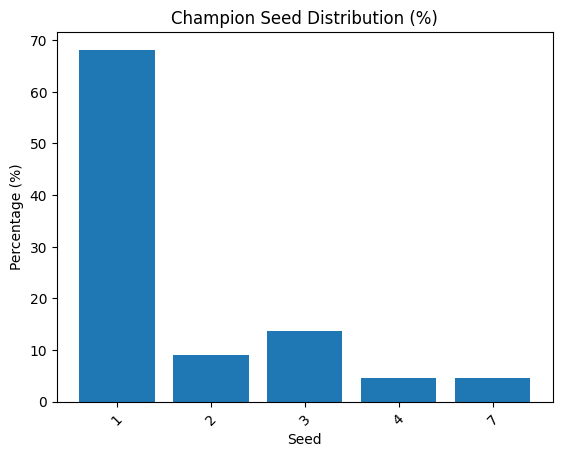

In [11]:
seed_pct = (
    champs['seed']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(seed_pct.index.astype(str), seed_pct.values)

plt.xlabel("Seed")
plt.ylabel("Percentage (%)")
plt.title("Champion Seed Distribution (%)")
plt.xticks(rotation=45)

plt.show()

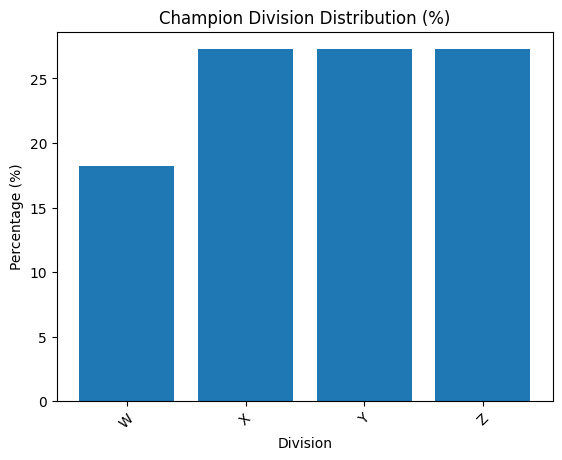

In [12]:
div_pct = (
    champs['division']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(div_pct.index.astype(str), div_pct.values)

plt.xlabel("Division")
plt.ylabel("Percentage (%)")
plt.title("Champion Division Distribution (%)")
plt.xticks(rotation=45)

plt.show()

In [13]:
tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Wseed'})

tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Lseed'})

In [14]:
tourney_results['seed_dif'] = tourney_results['Wseed'] - tourney_results['Lseed']
tourney_results['point_dif'] = tourney_results['WScore'] - tourney_results['LScore']

In [15]:
tourney_results[['seed_dif', 'point_dif']].corr()

,seed_dif,point_dif
seed_dif,1.000000,-0.394906
point_dif,-0.394906,1.000000


In [20]:
mens_season_stats.columns

Index(['games', 'is_win', 'possessions_avg', 'Score', 'FGM', 'FGA', 'FGM3',
       'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
       'opp_Score', 'opp_FGM', 'opp_FGA', 'opp_FGM3', 'opp_FGA3', 'opp_FTM',
       'opp_FTA', 'opp_OR', 'opp_DR', 'opp_Ast', 'opp_TO', 'opp_Stl',
       'opp_Blk', 'opp_PF', 'win_pct', 'fg_pct', 'fg3_pct', 'ft_pct',
       'opp_fg_pct', 'opp_fg3_pct', 'opp_ft_pct', 'off_rating', 'def_rating',
       'net_rating', 'efg', 'opp_efg', 'tov_rate', 'opp_tov_rate', 'ft_rate',
       'opp_ft_rate', 'orb_margin_pg', 'drb_margin_pg', 'pos_per_game',
       'seed'],
      dtype='object')

In [22]:
def add_team_clusters(df, pca_features, n_clusters=5, random_state=42):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    cluster_labels = kmeans.fit_predict(pca_features)

    out = df.copy()
    out["team_cluster"] = cluster_labels

    return out, kmeans

In [23]:
reduced_df, pca_group_dict, fitted_objects = group_pca(
    df=mens_season_stats
)

season_with_clusters, kmeans_model = add_team_clusters(
    df=mens_season_stats,
    pca_features=reduced_df,
    n_clusters=5,
    random_state=42
)

In [24]:
cluster_profile = (
    season_with_clusters
    .groupby("team_cluster")[
        [
            "off_rating", "def_rating", "net_rating",
            "efg", "opp_efg", "tov_rate", "opp_tov_rate",
            "OR", "DR", "possessions_avg"
        ]
    ]
    .mean()
    .round(3)
)

print(cluster_profile)

              off_rating  def_rating  net_rating    efg  opp_efg  tov_rate  \
team_cluster                                                                 
0                  1.101       1.002       0.099  0.536    0.487     0.174   
1                  1.033       0.969       0.064  0.497    0.472     0.196   
2                  1.014       1.053      -0.040  0.501    0.515     0.173   
3                  1.021       1.061      -0.040  0.501    0.517     0.188   
4                  0.942       1.039      -0.097  0.462    0.508     0.216   

              opp_tov_rate       OR       DR  possessions_avg  
team_cluster                                                   
0                    0.181  301.693  769.797         2142.209  
1                    0.207  358.645  757.240         2126.057  
2                    0.167  184.743  508.296         1561.875  
3                    0.183  287.456  687.539         2043.591  
4                    0.204  319.470  650.560         1964.224  


In [25]:
def add_matchup_clusters(matchup_df, season_features_df):
    team_clusters = (
        season_features_df[["team_cluster"]]
        .reset_index()
        .rename(columns={"TeamID": "TeamID", "team_cluster": "team_cluster"})
    )

    opp_clusters = (
        season_features_df[["team_cluster"]]
        .reset_index()
        .rename(columns={"TeamID": "OppTeamID", "team_cluster": "opp_cluster"})
    )

    out = matchup_df.merge(
        team_clusters,
        on=["Season", "TeamID"],
        how="left"
    )

    out = out.merge(
        opp_clusters,
        on=["Season", "OppTeamID"],
        how="left"
    )

    out["same_cluster"] = (out["team_cluster"] == out["opp_cluster"]).astype(int)

    return out

In [26]:
matchup_df = pd.get_dummies(
    matchup_df,
    columns=["team_cluster", "opp_cluster"],
    prefix=["team_cluster", "opp_cluster"],
    drop_first=False
)

NameError: name 'matchup_df' is not defined

In [ ]:
def transform_with_group_pca(df, fitted_objects):
    reduced = pd.DataFrame(index=df.index)

    for group_name, obj in fitted_objects.items():
        cols = obj["cols"]
        scaler = obj["scaler"]
        pca = obj["pca"]

        X = df[cols].copy()
        X_scaled = scaler.transform(X)
        X_pca = pca.transform(X_scaled)

        for i in range(X_pca.shape[1]):
            reduced[f"{group_name}_pca{i+1}"] = X_pca[:, i]

    return reduced

In [118]:
# 1. Build season stats -  DONE
# 2. Create efficiency metrics - DONE
# 3. Run PCA - Questionable?
# 4. Cluster teams - Questionable?
# 5. Build matchup dataset
# 6. Train XGBoost
# 7. Calibrate probabilities

# Ideas
### Compare avg regular season stats (scoring, defense, differentials)
### Understand how each team played against other types of team
###    - Did they play well against good defenses? 
###    - Are they more prone to lose if the other team is known for lots of offensive boards?